In [1]:
import numpy as np
_dataset_path = "mapelite/datasets/track_embeddings_metrics_32dim_rngMixDS_tita_circular_5.npz"
EMBEDDING_MODEL_PATH = "mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_circular_5.pth"
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]


# pairwise distances
from scipy.spatial.distance import pdist, squareform
distances = pdist(_embeddings, metric="euclidean")

max_distance = np.max(distances)
min_distance = np.min(distances)
average_distance = np.mean(distances)

diff = max_distance - min_distance
y = diff / min_distance

print(f"Max distance: {max_distance}")
print(f"Min distance: {min_distance}")
print(f"Difference: {diff}")
print(f"Difference / Min distance: {y}")
print(f"Average distance: {average_distance}")

Max distance: 14.68900268174536
Min distance: 0.055116299088354664
Difference: 14.633886382657005
Difference / Min distance: 265.50923455869247
Average distance: 5.365611749750249


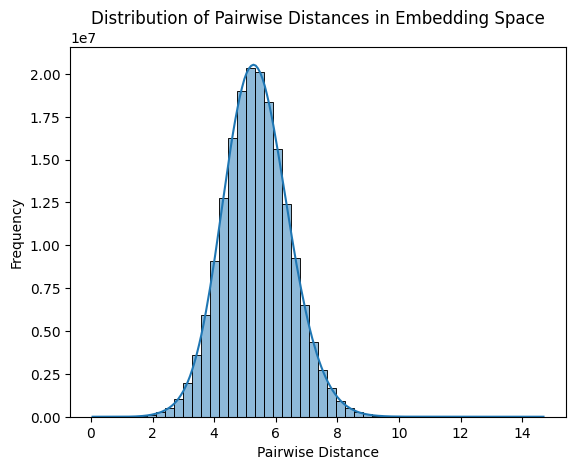

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(distances, bins=50, kde=True)
plt.xlabel("Pairwise Distance")
plt.ylabel("Frequency") 
plt.title("Distribution of Pairwise Distances in Embedding Space")
plt.show()

Dimension 0: Mean = -0.0437, Std Dev = 0.6528
Dimension 1: Mean = -0.2761, Std Dev = 0.7391
Dimension 2: Mean = 0.2510, Std Dev = 0.6379
Dimension 3: Mean = -0.2638, Std Dev = 0.6501
Dimension 4: Mean = -0.2980, Std Dev = 0.6525
Dimension 5: Mean = -0.2388, Std Dev = 0.7143
Dimension 6: Mean = -0.2360, Std Dev = 0.6484
Dimension 7: Mean = -0.1422, Std Dev = 0.7117
Dimension 8: Mean = -0.0970, Std Dev = 0.7110
Dimension 9: Mean = -0.0708, Std Dev = 0.5069
Dimension 10: Mean = 0.3024, Std Dev = 0.6475
Dimension 11: Mean = -0.2007, Std Dev = 0.6812
Dimension 12: Mean = -0.0817, Std Dev = 0.7222
Dimension 13: Mean = 0.0325, Std Dev = 0.6850
Dimension 14: Mean = -0.2053, Std Dev = 0.6430
Dimension 15: Mean = 0.2998, Std Dev = 0.6861
Dimension 16: Mean = -0.2431, Std Dev = 0.6754
Dimension 17: Mean = -0.0107, Std Dev = 0.7661
Dimension 18: Mean = -0.4251, Std Dev = 0.6588
Dimension 19: Mean = -0.0830, Std Dev = 0.6233
Dimension 20: Mean = 0.1535, Std Dev = 0.6131
Dimension 21: Mean = -0.3852

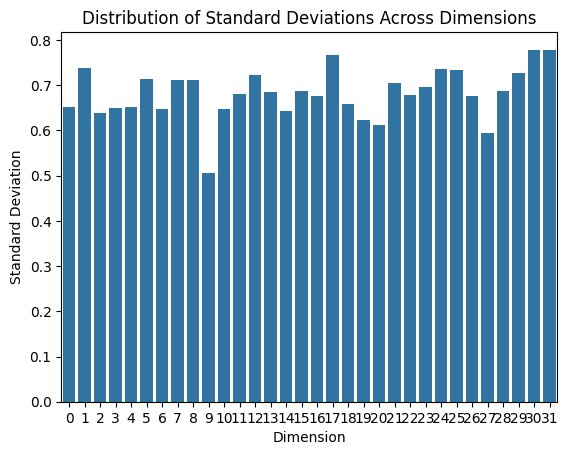

In [3]:
# for each dimention calculate the mean and std_deviation
for i in range(_embeddings.shape[1]):
    dim_values = _embeddings[:, i]
    mean = np.mean(dim_values)
    std_dev = np.std(dim_values)
    print(f"Dimension {i}: Mean = {mean:.4f}, Std Dev = {std_dev:.4f}")
    
# make a barplot of the std_deviation of each dimension
std_devs = [np.std(_embeddings[:, i]) for i in range(_embeddings.shape[1])]
sns.barplot(x=list(range(len(std_devs))), y=std_devs)
plt.xlabel("Dimension")
plt.ylabel("Standard Deviation")
plt.title("Distribution of Standard Deviations Across Dimensions")
plt.show()

Autovalori: [1.24703819 1.19024739 1.05439643 1.00975069 0.96656813 0.93806463
 0.89714071 0.80599715 0.77198624 0.69437051 0.67161766 0.6074546
 0.5755546  0.51188366 0.4417757  0.43148032 0.39872278 0.35055077
 0.28120196 0.25320141 0.21793948 0.1767962  0.13995094 0.10872415
 0.07834522 0.05735293 0.04382572 0.02182374 0.01078342 0.00234248
 0.00611908 0.003923  ]


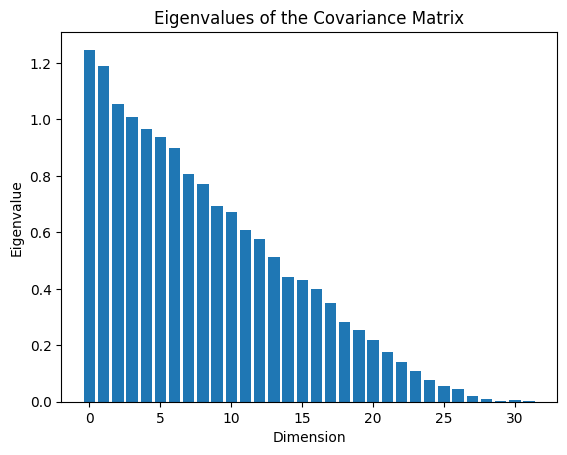

In [4]:
# covariance matrix and eigenvalues
cov_matrix = np.cov(_embeddings, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Autovalori:", eigenvalues)

# bar plot of eigenvalues
plt.bar(range(len(eigenvalues)), eigenvalues)
plt.xlabel("Dimension")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalues of the Covariance Matrix")
plt.show()